REDES NEURONALES

LAB5

Estudiante: Chelsea M. Espinoza Cava

Carrera: Ing. de Sistemas

In [11]:
import torch
# Módulos para construir capas de la red
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#train y test
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
#Metrica de evaluacion
from sklearn.metrics import accuracy_score
# Imputación avanzada por similitud de vecinos
from sklearn.impute import KNNImputer
import os

In [12]:
# 1. CARGAR EL ARCHIVO
ruta = r'C:\Users\Mi Chelsy\Documents\GitHub\IA26\LAB5\TrainingWiDS2021.csv'
df = pd.read_csv(ruta)

# 2. SELECCIÓN DE COLUMNAS NUMÉRICAS
df_numeric = df.select_dtypes(include=[np.number])

# 3. SEPARAR X y Y
target_col = 'diabetes_mellitus' 
X = df_numeric.drop(columns=[target_col]).values
y = df_numeric[target_col].values

# 4. LIMPIAR NaNs
imputer = SimpleImputer(strategy='mean')
X_clean = imputer.fit_transform(X)

## 4. LIMPIEZA POR SIMILITUD (KNN)
# n_neighbors=5: Busca a los 5 pacientes más parecidos para deducir el dato
#imputer = KNNImputer(n_neighbors=5)
# Aplicamos la limpieza basada en "vecinos similares"
#X_clean = imputer.fit_transform(X)

print("¡Limpieza exitosa! Se eliminaron las columnas de texto para evitar errores de conversión.")

¡Limpieza exitosa! Se eliminaron las columnas de texto para evitar errores de conversión.


In [13]:
print(f"Total: {df}")

Total:         Unnamed: 0  encounter_id  hospital_id   age        bmi  \
0                1        214826          118  68.0  22.732803   
1                2        246060           81  77.0  27.421875   
2                3        276985          118  25.0  31.952749   
3                4        262220          118  81.0  22.635548   
4                5        201746           33  19.0        NaN   
...            ...           ...          ...   ...        ...   
130152      130153        164758            7  50.0  29.287256   
130153      130154        197653            7  79.0  29.653433   
130154      130155        219719            7  73.0  32.265371   
130155      130156        222562          170  81.0  24.408579   
130156      130157        157942            7  35.0  30.132358   

        elective_surgery         ethnicity gender  height  \
0                      0         Caucasian      M   180.3   
1                      0         Caucasian      F   160.0   
2                

In [14]:
# 5. DIVISIÓN 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.20, random_state=42
)

# 6. NORMALIZACIÓN
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0 

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

# 7. CONVERTIR A TENSORES
X_t = torch.from_numpy(X_train_norm).float()
Y_t = torch.from_numpy(y_train).long()
X_test_t = torch.from_numpy(X_test_norm).float()

print(f"Número de muestras para ENTRENAR (X_t): {X_t.shape[0]}")
print(f"Número de muestras para EVALUAR (X_test_t): {X_test_t.shape[0]}")

Número de muestras para ENTRENAR (X_t): 104125
Número de muestras para EVALUAR (X_test_t): 26032


In [15]:
# 8. CLASE DATASET Y DATALOADER
class DiabetesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = DiabetesDataset(X_t, Y_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [16]:
dataset = DiabetesDataset(X_t, Y_t)

len(dataset)

104125

In [17]:
# 9. DEFINICIÓN DEL MODELO
D_in = X_t.shape[1]
H = 256  # Un cerebro equilibrado
D_out = 2

model = nn.Sequential(
    nn.Linear(D_in, H),
    nn.ReLU(),
    nn.Linear(H, 128), # Añadimos una capa extra para suavizar la transición
    nn.ReLU(),
    nn.Linear(128, D_out)
)

criterion = nn.CrossEntropyLoss()

# REDUCIMOS EL LR: 0.001 con Adam es el punto dulce para curvas suaves
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007) 

# Aumentamos el Batch Size a 128 para que el promedio de error sea más estable
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

# 10. BUCLE DE ENTRENAMIENTO
epochs = 200 # Más épocas con un LR bajo hará que la curva sea larga y suave
history = []

model.train()
for e in range(1, epochs + 1):
    epoch_losses = []
    for x_b, y_b in train_loader:
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    
    # Guardamos el promedio de la época para la gráfica
    history.append(np.mean(epoch_losses))
    
    if e % 10 == 0:
        print(f"Época {e}/{epochs} - Pérdida: {history[-1]:.5f}")


Época 10/200 - Pérdida: 0.32041
Época 20/200 - Pérdida: 0.20406
Época 30/200 - Pérdida: 0.12265
Época 40/200 - Pérdida: 0.08279
Época 50/200 - Pérdida: 0.05949
Época 60/200 - Pérdida: 0.04519
Época 70/200 - Pérdida: 0.04368
Época 80/200 - Pérdida: 0.03140
Época 90/200 - Pérdida: 0.02883
Época 100/200 - Pérdida: 0.03263
Época 110/200 - Pérdida: 0.02864
Época 120/200 - Pérdida: 0.02359
Época 130/200 - Pérdida: 0.02902
Época 140/200 - Pérdida: 0.02762
Época 150/200 - Pérdida: 0.02250
Época 160/200 - Pérdida: 0.02745
Época 170/200 - Pérdida: 0.02063
Época 180/200 - Pérdida: 0.01844
Época 190/200 - Pérdida: 0.01470
Época 200/200 - Pérdida: 0.02004


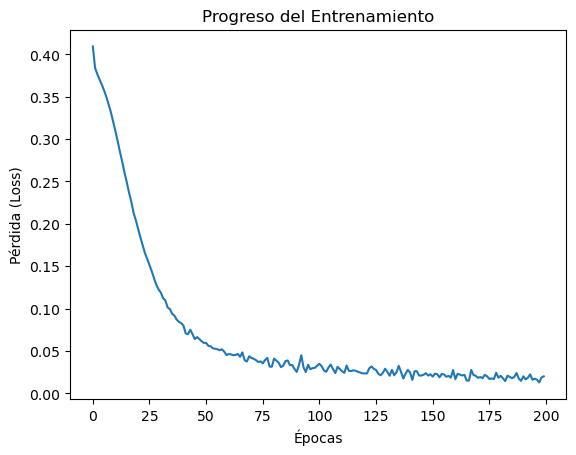

In [18]:
# 11. GRÁFICA DE PÉRDIDA
plt.plot(history)
plt.title('Progreso del Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.show()

In [19]:
# 12. EVALUACIÓN FINAL
model.eval()
with torch.no_grad():
    y_pred_raw = model(X_test_t)
    y_pred_labels = torch.argmax(y_pred_raw, axis=1)

acc = accuracy_score(y_test, y_pred_labels.numpy())
print(f"\n--- RESULTADO FINAL ---")
print(f"Accuracy en CPU: {acc * 100:.2f}%")


--- RESULTADO FINAL ---
Accuracy en CPU: 78.07%


In [ ]:
# 13. GUARDAR CHECKPOINT
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_dim': D_in,
    'mean': mean,
    'std': std
}
torch.save(checkpoint, 'checkpoint_chelsea_final.pth')
print("Checkpoint guardado exitosamente.")

Laboratorio finalizado y checkpoint guardado exitosamente.
